In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv("noisy_curvefit_data.csv")

In [3]:
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("First five rows:")
print(df.head())

print("Last five rows:")
print(df.tail())

print("Column names:")
print(df.columns)

Shape: (100, 6)
Rows: 100
Columns: 6
First five rows:
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
Last five rows:
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850
Column names:
Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')


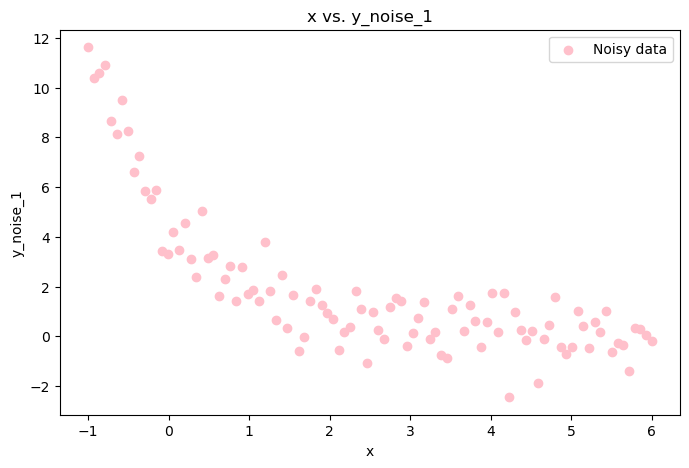

In [5]:
x = df["x"]
y_noise_1 = df["y_noise_1"]

plt.figure(figsize=(8, 5))
plt.scatter(x, y_noise_1, color="pink", label="Noisy data")
plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.title("x vs. y_noise_1")
plt.legend()
plt.show()

Fit: y = 4.71 * e^(-0.92 * x)
Reduced chi-squared: 0.79


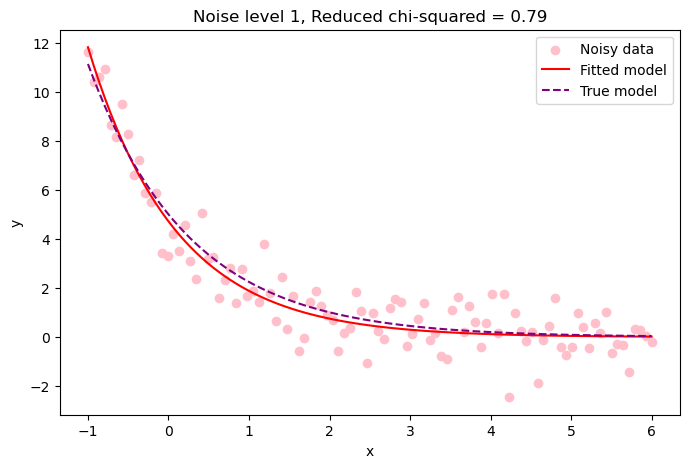

In [8]:
def model(x, A, k):
    return A * np.exp(-k * x)

p0 = [1, 1]

popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)

A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)   # n - p
chi2_reduced = chi2 / dof

print(f"Reduced chi-squared: {chi2_reduced:.2f}")

plt.figure(figsize=(8, 5))

plt.scatter(x, y_noise_1, color="pink", label="Noisy data")
plt.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted model")
plt.plot(x, model(x, 5, 0.8), color="purple", linestyle="--", label="True model")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Noise level 1, Reduced chi-squared = {chi2_reduced:.2f}")
plt.legend()
plt.show()

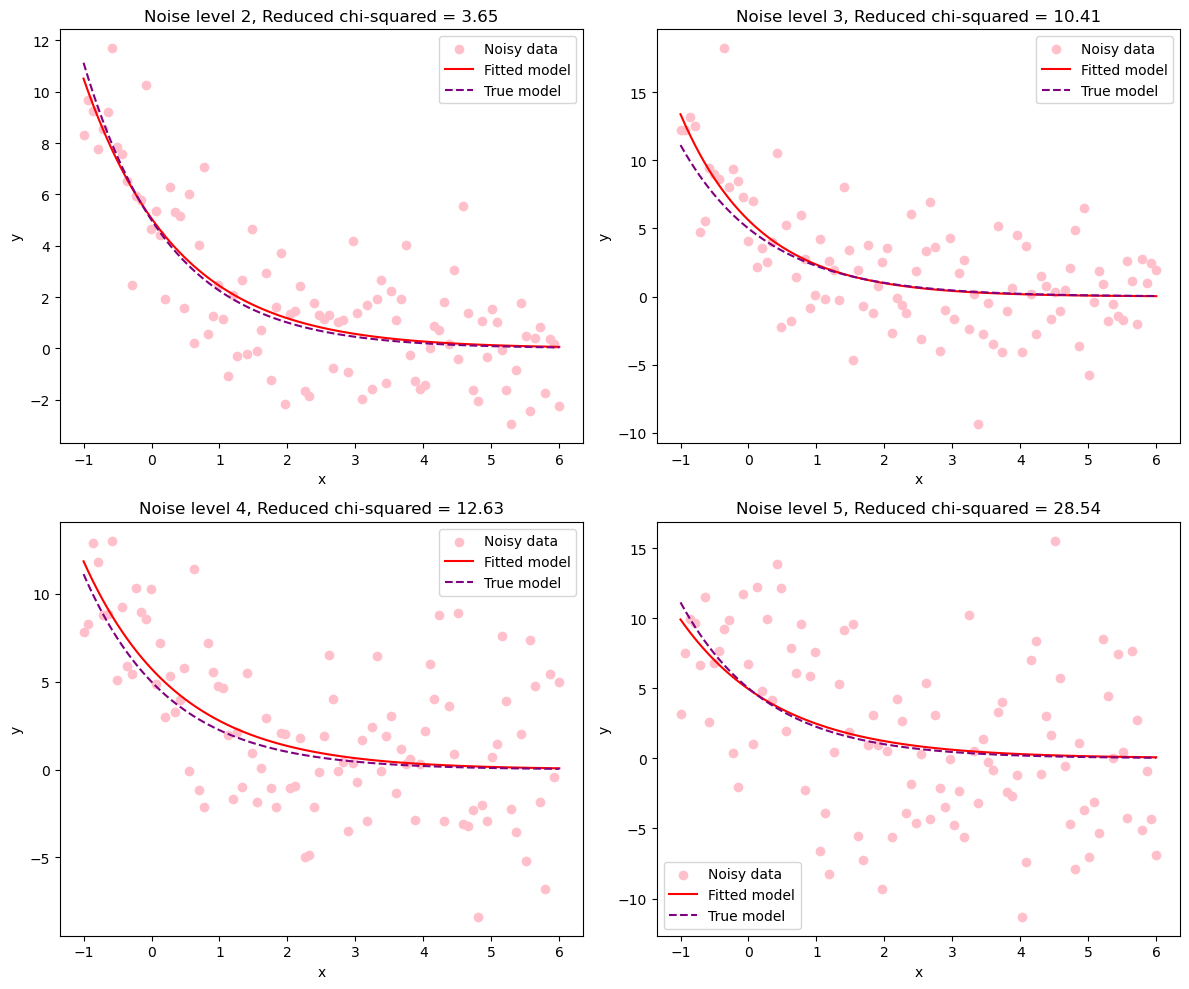

In [10]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    
    return A_fit, k_fit, chi2_reduced

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

noise_columns = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]

for i, col in enumerate(noise_columns):
    y = df[col]
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    
    axes[i].scatter(x, y, color="pink", label="Noisy data")
    axes[i].plot(x, model(x, A_fit, k_fit), color="red", label="Fitted model")
    axes[i].plot(x, model(x, 5, 0.8), color="purple", linestyle="--", label="True model")
    
    noise_level = i + 2
    axes[i].set_title(f"Noise level {noise_level}, Reduced chi-squared = {chi2_reduced:.2f}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")
    axes[i].legend()

plt.tight_layout()
plt.show()

In [11]:
#2.2.4 questions
#a. As noise level increases, the noisy data points spread out more.
    #because of that, the fitted curve matches the purple curve less closely. 
#b. the reduced chi-squared generally increase
    #because residuals between the data and fitted model become larger. 

In [14]:
results = []

for i in range(1, 6):
    col = f"y_noise_{i}"
    y = df[col]
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    
    results.append({
        "Noise level": i,
        "A fit": A_fit,
        "k fit": k_fit,
        "Reduced chi-squared": chi2_reduced
    })

results_df = pd.DataFrame(results)
print(results_df)

results_df.to_csv("noisy_parameters.csv", index=False)

   Noise level     A fit     k fit  Reduced chi-squared
0            1  4.714814  0.918308             0.790673
1            2  5.063889  0.730396             3.649382
2            3  5.609396  0.870372            10.410207
3            4  5.738727  0.725965            12.626832
4            5  4.943458  0.695012            28.538124
